# NO Conversion AutoGluon Training

Train AutoGluon models on the NO selective catalytic reduction dataset.
Target: **Conversion** (maximize).

Supports four `sep` modes:
- `sep` : raw categorical `method` + all numeric features
- `m1`  : merged Phase-I identifier
- `m12` : merged Phase-I & II identifier
- `m1m2`: two separate merged identifiers

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from autogluon.tabular import TabularPredictor
import warnings
warnings.filterwarnings('ignore')

/home/sjtu/.conda/envs/CAS/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration
Set `SEP_MODE` to one of `'sep'`, `'m1'`, `'m12'`, `'m1m2'`.

In [4]:
SEP_MODE        = 'sep'   # 'sep' | 'm1' | 'm12' | 'm1m2'
TIME_LIMIT      = 600     # seconds for AutoGluon training
TRAIN_RATIO     = 0.7
RANDOM_STATE    = 42

CURRENT_DIR  = os.path.dirname(os.path.abspath('__file__'))
DATA_PATH    = os.path.join(CURRENT_DIR, 'SCR.csv')

# Model save paths
MODEL_PATHS = {
    'sep' : os.path.join(CURRENT_DIR, 'AutogluonModels', 'NO'),
    'm1'  : os.path.join(CURRENT_DIR, 'AutogluonModels', 'NO_m1'),
    'm12' : os.path.join(CURRENT_DIR, 'AutogluonModels', 'NO_m12'),
    'm1m2': os.path.join(CURRENT_DIR, 'AutogluonModels', 'NO_m1m2'),
}
SAVE_PATH = MODEL_PATHS[SEP_MODE]
print(f'sep mode : {SEP_MODE}')
print(f'save path: {SAVE_PATH}')

sep mode : sep
save path: /home/sjtu/CASMOPOLITAN/mixed_test_func/SCR/AutogluonModels/NO


## Load & Prepare Data

In [7]:
data = pd.read_csv(DATA_PATH, index_col=None)
data['y'] = data['Conversion']
print(f'Dataset shape: {data.shape}')
data.head()

Dataset shape: (4289, 22)


,Fe\nwt %,Cu\nwt %,species,Si/Al,method,calcination \ntemperature (℃),calcination \ntime (h),Aging_O2\n(%),Aging_H2O\n(%),Aging_CO2\n(%),...,NO\n(ppm),NH3\n(ppm),O2\n(%),H2O\n(%),CO2\n(%),GHSV\n(10^5 * h^{-1}),Exp_Temp,Measurement_Temp,Conversion,y
0,2.5,0.0,ZSM-5,10.0,IWI,550.0,6.0,14.0,4.5,5.0,...,1000.0,1000.0,2.0,0.0,0.0,1.9,Temperature,149.320831,3.370787,3.370787
1,2.5,0.0,ZSM-5,10.0,IWI,550.0,6.0,14.0,4.5,5.0,...,1000.0,1000.0,2.0,0.0,0.0,1.9,Temperature,200.127921,17.977528,17.977528
2,2.5,0.0,ZSM-5,10.0,IWI,550.0,6.0,14.0,4.5,5.0,...,1000.0,1000.0,2.0,0.0,0.0,1.9,Temperature,248.921243,46.629213,46.629213
3,2.5,0.0,ZSM-5,10.0,IWI,550.0,6.0,14.0,4.5,5.0,...,1000.0,1000.0,2.0,0.0,0.0,1.9,Temperature,299.174447,82.584270,82.584270
4,2.5,0.0,ZSM-5,10.0,IWI,550.0,6.0,14.0,4.5,5.0,...,1000.0,1000.0,2.0,0.0,0.0,1.9,Temperature,349.956480,93.632959,93.632959


In [8]:
def prepare_features(data, sep_mode):
    df = data.copy()
    le = LabelEncoder()

    if sep_mode == 'sep':
        cat_var  = ['species','method']
        cont_var = ['Fe', 'Cu', 'Si_Al', 'calcination_temp', 'calcination_time',
                    'Aging_O2', 'Aging_H2O', 'Aging_CO2', 'Aging_Balance_gas',
                    'Aging_Temp', 'Aging_Time',
                    'NO', 'NH3', 'O2', 'H2O', 'Balance_gas', 'GHSV', 'Measurement_Temp']

    elif sep_mode == 'm1':
        df['m1'] = (df['Fe'].astype(str) + '|' + df['Cu'].astype(str) + '|' +
                    df['Si_Al'].astype(str) + '|' + df['method'].astype(str) + '|' +
                    df['calcination_temp'].astype(str) + '|' + df['calcination_time'].astype(str))
        cat_var  = ['m1']
        cont_var = ['Aging_O2', 'Aging_H2O', 'Aging_CO2', 'Aging_Balance_gas',
                    'Aging_Temp', 'Aging_Time',
                    'NO', 'NH3', 'O2', 'H2O', 'Balance_gas', 'GHSV', 'Measurement_Temp']

    elif sep_mode == 'm12':
        df['m12'] = (df['Fe'].astype(str) + '|' + df['Cu'].astype(str) + '|' +
                     df['Si_Al'].astype(str) + '|' + df['method'].astype(str) + '|' +
                     df['calcination_temp'].astype(str) + '|' + df['calcination_time'].astype(str) + '|' +
                     df['Aging_O2'].astype(str) + '|' + df['Aging_H2O'].astype(str) + '|' +
                     df['Aging_CO2'].astype(str) + '|' + df['Aging_Balance_gas'].astype(str) + '|' +
                     df['Aging_Temp'].astype(str) + '|' + df['Aging_Time'].astype(str))
        cat_var  = ['m12']
        cont_var = ['NO', 'NH3', 'O2', 'H2O', 'Balance_gas', 'GHSV', 'Measurement_Temp']

    elif sep_mode == 'm1m2':
        df['m1'] = (df['Fe'].astype(str) + '|' + df['Cu'].astype(str) + '|' +
                    df['Si_Al'].astype(str) + '|' + df['method'].astype(str) + '|' +
                    df['calcination_temp'].astype(str) + '|' + df['calcination_time'].astype(str))
        df['m2'] = (df['Aging_O2'].astype(str) + '|' + df['Aging_H2O'].astype(str) + '|' +
                    df['Aging_CO2'].astype(str) + '|' + df['Aging_Balance_gas'].astype(str) + '|' +
                    df['Aging_Temp'].astype(str) + '|' + df['Aging_Time'].astype(str))
        cat_var  = ['m1', 'm2']
        cont_var = ['NO', 'NH3', 'O2', 'H2O', 'Balance_gas', 'GHSV', 'Measurement_Temp']

    else:
        raise ValueError(f'Unknown sep_mode: {sep_mode}')

    # Encode categoricals
    for col in cat_var:
        df[col] = le.fit_transform(df[col].astype(str))
        df[col] = df[col].astype('category')
    for col in cont_var:
        df[col] = df[col].astype('float')

    feature_cols = cat_var + cont_var
    return df[feature_cols + ['y']], cat_var, cont_var

df_model, cat_var, cont_var = prepare_features(data, SEP_MODE)
print(f'Features : {cat_var + cont_var}')
print(f'Rows     : {len(df_model)}')
df_model.head()

KeyError: 'Fe'

## Train / Test Split

In [6]:
train_data = df_model.sample(frac=TRAIN_RATIO, random_state=RANDOM_STATE)
test_data  = df_model.drop(train_data.index)
print(f'Train: {len(train_data)}  |  Test: {len(test_data)}')

Train: 778  |  Test: 334


## Train AutoGluon Model

Training with `presets='best_quality'` and `time_limit=600s`.  
The model will be saved to `AutogluonModels/NO` (for `sep` mode).

In [7]:
predictor = TabularPredictor(
    label='y',
    eval_metric='mean_absolute_error',
    path=SAVE_PATH
).fit(
    train_data,
    time_limit=TIME_LIMIT,
    presets='medium_quality'
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.2
Python Version:     3.10.5
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #129~20.04.1-Ubuntu SMP Wed Aug 7 13:07:13 UTC 2024
CPU Count:          32
Memory Avail:       90.41 GB / 125.73 GB (71.9%)
Disk Space Avail:   957.25 GB / 1773.01 GB (54.0%)
Presets specified: ['medium_quality']
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/home/sjtu/CASMOPOLITAN/mixed_test_func/NO/AutogluonModels/NO"
Train Data Rows:    778
Train Data Columns: 18
Label Column:       y
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, min, mean, stddev): (100.1559943, 0.0, 60.90008, 31.66072)
	If 'regression' is not the correct problem_type, please manually specify the problem_type parameter during Predictor init (You may specify problem_ty

[1000]	valid_set's l1: 7.15671
[2000]	valid_set's l1: 6.64885
[3000]	valid_set's l1: 6.37378
[4000]	valid_set's l1: 6.30853
[5000]	valid_set's l1: 6.25303
[6000]	valid_set's l1: 6.21347
[7000]	valid_set's l1: 6.18808
[8000]	valid_set's l1: 6.15841
[9000]	valid_set's l1: 6.15074
[10000]	valid_set's l1: 6.12438


	-6.124	 = Validation score   (-mean_absolute_error)
	4.16s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 595.48s of the 595.48s of remaining time.


[1000]	valid_set's l1: 6.298
[2000]	valid_set's l1: 6.06066
[3000]	valid_set's l1: 5.96298
[4000]	valid_set's l1: 5.91509
[5000]	valid_set's l1: 5.87645
[6000]	valid_set's l1: 5.85476
[7000]	valid_set's l1: 5.84425
[8000]	valid_set's l1: 5.8403
[9000]	valid_set's l1: 5.83723
[10000]	valid_set's l1: 5.83251


	-5.8324	 = Validation score   (-mean_absolute_error)
	5.42s	 = Training   runtime
	0.02s	 = Validation runtime
Fitting model: RandomForestMSE ... Training model for up to 589.85s of the 589.85s of remaining time.
	-8.3833	 = Validation score   (-mean_absolute_error)
	0.45s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: CatBoost ... Training model for up to 589.28s of the 589.28s of remaining time.
	-6.1489	 = Validation score   (-mean_absolute_error)
	71.98s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: ExtraTreesMSE ... Training model for up to 517.23s of the 517.23s of remaining time.
	-7.4847	 = Validation score   (-mean_absolute_error)
	0.46s	 = Training   runtime
	0.06s	 = Validation runtime
Fitting model: NeuralNetFastAI ... Training model for up to 516.65s of the 516.65s of remaining time.
	-9.6666	 = Validation score   (-mean_absolute_error)
	2.04s	 = Training   runtime
	0.01s	 = Validation runtime
Fitting model: XGBoost ... Training mode

## Evaluation on Test Set

In [8]:
leaderboard = predictor.leaderboard(test_data, extra_metrics=['mae'], silent=True)
print(leaderboard[['model', 'score_val', 'eval_metric']].set_index('model').to_string())

                     score_val          eval_metric
model                                              
WeightedEnsemble_L2  -4.406709  mean_absolute_error
CatBoost             -6.148944  mean_absolute_error
LightGBMXT           -6.123972  mean_absolute_error
NeuralNetTorch       -4.812297  mean_absolute_error
LightGBM             -5.832396  mean_absolute_error
XGBoost              -6.915686  mean_absolute_error
LightGBMLarge        -7.649096  mean_absolute_error
ExtraTreesMSE        -7.484712  mean_absolute_error
RandomForestMSE      -8.383326  mean_absolute_error
NeuralNetFastAI      -9.666632  mean_absolute_error
KNeighborsDist      -10.661183  mean_absolute_error
KNeighborsUnif      -13.078833  mean_absolute_error


In [13]:
y_pred = predictor.predict(test_data.drop(columns=['y']))
y_true = test_data['y']
mae  = np.mean(np.abs(y_pred.values - y_true.values))
rmse = np.sqrt(np.mean((y_pred.values - y_true.values) ** 2))
r2   = 1 - np.sum((y_true.values - y_pred.values)**2) / np.sum((y_true.values - y_true.mean())**2)
print(f'Test MAE : {mae:.4f}')
print(f'Test RMSE: {rmse:.4f}')
print(f'Test R²  : {r2:.4f}')

Test MAE : 4.9544
Test RMSE: 8.3601
Test R²  : 0.9364


## Prediction vs Ground Truth

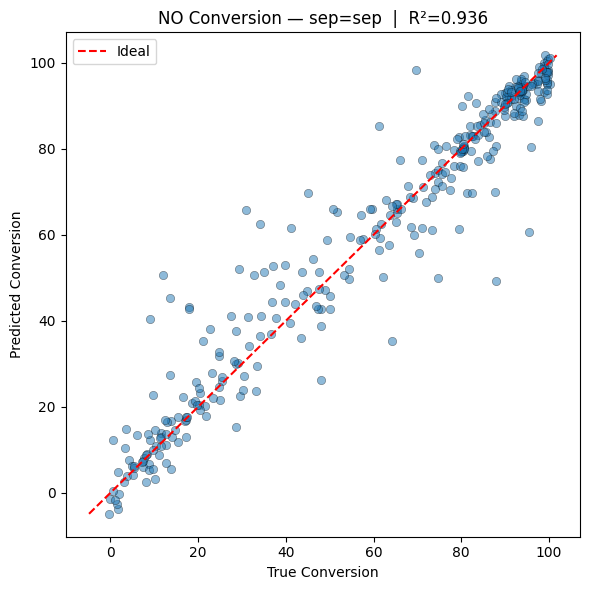

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_true, y_pred, alpha=0.5, edgecolors='k', linewidths=0.4)
lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', lw=1.5, label='Ideal')
ax.set_xlabel('True Conversion')
ax.set_ylabel('Predicted Conversion')
ax.set_title(f'NO Conversion — sep={SEP_MODE}  |  R²={r2:.3f}')
ax.legend()
plt.tight_layout()
plt.show()

## Load & Quick Verify Saved Model

In [15]:
loaded = TabularPredictor.load(SAVE_PATH)
sample = test_data.drop(columns=['y']).iloc[:3]
print('Sample predictions:')
print(loaded.predict(sample).values)

Sample predictions:
[43.26761  92.919464 37.028736]
